In [2]:
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [5]:
df = pd.read_csv('scaled.csv')
df.dropna(inplace=True)

X = df["title"]
y = df["Label"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
log_model = joblib.load("logistic_fake_news_model.pkl")
svm_model = joblib.load("svm_fake_news_model.pkl")
nb_model = joblib.load("naive_bayes_fake_news_model.pkl")
rf_model = joblib.load("random_forest_fake_news_model.pkl")

In [8]:
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [9]:
X_test_vec = vectorizer.transform(X_test)

In [10]:
log_pred = log_model.predict(X_test_vec)
svm_pred = svm_model.predict(X_test_vec)
nb_pred = nb_model.predict(X_test_vec)
rf_pred = rf_model.predict(X_test_vec)

In [11]:
log_acc = accuracy_score(y_test, log_pred)
svm_acc = accuracy_score(y_test, svm_pred)
nb_acc = accuracy_score(y_test, nb_pred)
rf_acc = accuracy_score(y_test, rf_pred)

In [12]:
log_acc

0.8259400388237832

In [13]:
svm_acc

0.8254727155079445

In [14]:
nb_acc

0.782622762240276

In [15]:
rf_acc

0.8243583291394061

In [17]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Naive Bayes", "Random Forest"],
    "Accuracy": [log_acc, svm_acc, nb_acc, rf_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.825940
1,SVM,0.825473
2,Naive Bayes,0.782623
3,Random Forest,0.824358


In [19]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("\nBest Model:")
best_model


Best Model:


Model       Logistic Regression
Accuracy                0.82594
Name: 0, dtype: object

In [20]:
import matplotlib.pyplot as plt

In [24]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Naive Bayes", "Random Forest"],
    "Accuracy": [0.825940,0.825473 , 0.782623, 0.824358]
})

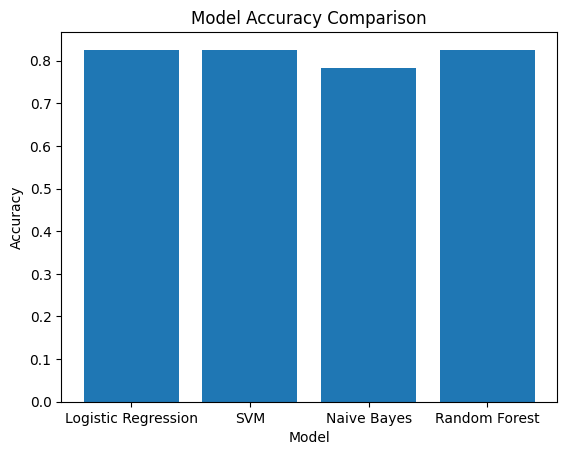

In [25]:
plt.figure()

plt.bar(results["Model"], results["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

In [23]:
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score

In [26]:
tokenizer = BertTokenizer.from_pretrained("fake_news_model")
bert_model = BertForSequenceClassification.from_pretrained("fake_news_model")

bert_model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [29]:
df = pd.read_csv('scaled.csv')
df.dropna(inplace=True)

X = df["title"]
y = df["Label"]

In [30]:
bert_predictions = []

for text in X:

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    outputs = bert_model(**inputs)

    pred = torch.argmax(outputs.logits).item()

    bert_predictions.append(pred)

In [31]:
bert_accuracy = accuracy_score(y, bert_predictions)

print("BERT Accuracy:", bert_accuracy)

BERT Accuracy: 0.8944049810192108


In [32]:
result = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Naive Bayes", "Random Forest","BERT"],
    "Accuracy": [0.825940,0.825473 , 0.782623, 0.824358,0.8944049810192108]
})

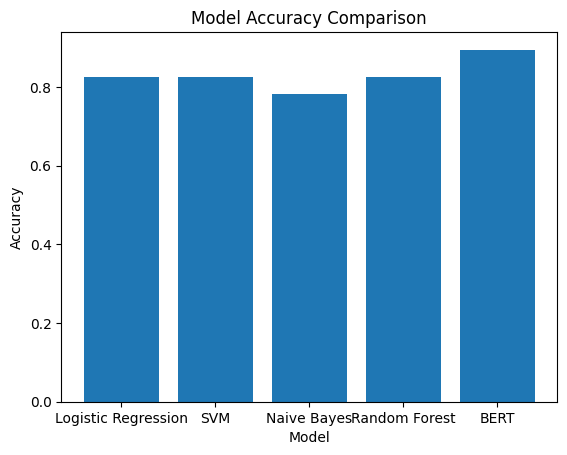

In [33]:
plt.figure()

plt.bar(result["Model"], result["Accuracy"])

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()